# The Effects of Tip Credit Elimination on Tipped Worker Earnings and Employment

### A Difference-in-Differences Analysis of Washington D.C.'s Initiative 82

This notebook contains the full data construction and econometric analysis behind my senior thesis (ECON 4692), which estimates the wage and employment effects of Washington D.C.'s gradual elimination of the tipped minimum wage credit. See `write-up.pdf` for the full paper, including literature review, discussion, and policy implications.

**Method**: Two-way fixed effects (TWFE) panel regression, using Washington D.C. as the treatment group and nearby Maryland/Virginia counties as controls, with data from the BLS Quarterly Census of Employment and Wages (QCEW), 2017 Q1 - 2025 Q2.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

## 2. Load Data

Two source files:
- `qcew_dc_metro_restaurants_2017_2025.csv`: BLS QCEW quarterly employment and wage data for full-service restaurants (NAICS 722511) across Washington D.C. and 9 nearby Maryland/Virginia counties, 2017-2025
- `census_population_by_county_2010_2024.csv`: Annual Census population estimates for the same 10 areas, used to construct an employment rate variable

In [3]:
data = pd.read_csv("data/qcew_dc_metro_restaurants_2017_2025.csv")
pop = pd.read_csv("data/census_population_by_county_2010_2024.csv")

## 3. Clean and Merge Population Data

The population file has minor formatting inconsistencies in area names (leading periods, inconsistent capitalization, and D.C./Alexandria naming that doesn't match the QCEW file) that need to be standardized before merging.

In [4]:
pop['area_title'] = pop['area_title'].str.lstrip('.')
pop['area_title'] = pop['area_title'].str.strip()  # catch any leftover whitespace
pop['area_title'] = pop['area_title'].str.replace('District of Columbia, District of Columbia', 'District of Columbia', regex=False)
pop['area_title'] = pop['area_title'].str.replace('Alexandria city, Virginia', 'Alexandria City, Virginia', regex=False)

Population data is stored wide (one column per year). Reshape to long format so it can be merged onto the quarterly QCEW panel by area and year.

In [5]:
pop_long = pop.melt(id_vars='area_title', var_name='year', value_name='population')
pop_long['year'] = pop_long['year'].astype(float)

In [6]:
data = data.merge(pop_long, on=['area_title', 'year'], how='left')
print(f"Missing population values after merge: {data['population'].isna().sum()}")

Missing population values after merge: 28


2025 has no population estimate yet (Census data lags), so forward-fill each area's most recent known population to cover the 2025 quarters.

In [7]:
data['population'] = data.groupby('area_title')['population'].ffill()

In [8]:
data.head()

,area_fips,own_code,industry_code,agglvl_code,size_code,year,qtr,disclosure_code,area_title,own_title,industry_title,agglvl_title,size_title,qtrly_estabs_count,month1_emplvl,month2_emplvl,month3_emplvl,total_qtrly_wages,taxable_qtrly_wages,qtrly_contributions,avg_wkly_wage,lq_disclosure_code,lq_qtrly_estabs_count,lq_month1_emplvl,lq_month2_emplvl,lq_month3_emplvl,lq_total_qtrly_wages,lq_taxable_qtrly_wages,lq_qtrly_contributions,lq_avg_wkly_wage,oty_disclosure_code,oty_qtrly_estabs_count_chg,oty_qtrly_estabs_count_pct_chg,oty_month1_emplvl_chg,oty_month1_emplvl_pct_chg,oty_month2_emplvl_chg,oty_month2_emplvl_pct_chg,oty_month3_emplvl_chg,oty_month3_emplvl_pct_chg,oty_total_qtrly_wages_chg,oty_total_qtrly_wages_pct_chg,oty_taxable_qtrly_wages_chg,oty_taxable_qtrly_wages_pct_chg,oty_qtrly_contributions_chg,oty_qtrly_contributions_pct_chg,oty_avg_wkly_wage_chg,oty_avg_wkly_wage_pct_chg,population
0,11001,1,722511,78,0,2017,1,NaN,District of Columbia,Federal Government,NAICS 722511 Full-service restaurants,"County, NAICS 6-digit -- by ownership sector",All establishment sizes,1,420,418,418,2156800,0,0,396,NaN,2.100,27.410,26.570,27.130,16.010,0.000,0.000,0.590,NaN,0,0.000,0,0.000,0,0.000,0,0.000,0,0.000,0,0.000,0,0.000,0,0.000,680670.000
1,11001,1,722511,78,0,2017,2,NaN,District of Columbia,Federal Government,NAICS 722511 Full-service restaurants,"County, NAICS 6-digit -- by ownership sector",All establishment sizes,1,420,418,418,2156800,0,0,396,NaN,2.170,27.660,27.570,27.620,15.880,0.000,0.000,0.570,NaN,0,0.000,0,0.000,0,0.000,0,0.000,0,0.000,0,0.000,0,0.000,0,0.000,680670.000
2,11001,1,722511,78,0,2017,3,NaN,District of Columbia,Federal Government,NAICS 722511 Full-service restaurants,"County, NAICS 6-digit -- by ownership sector",All establishment sizes,1,420,418,418,2156800,0,0,396,NaN,2.110,27.190,26.430,26.870,15.030,0.000,0.000,0.560,NaN,0,0.000,0,0.000,0,0.000,0,0.000,0,0.000,0,0.000,0,0.000,0,0.000,680670.000
3,11001,1,722511,78,0,2017,4,NaN,District of Columbia,Federal Government,NAICS 722511 Full-service restaurants,"County, NAICS 6-digit -- by ownership sector",All establishment sizes,1,420,418,418,2156800,0,0,396,NaN,2.070,27.130,27.070,26.940,15.700,0.000,0.000,0.580,NaN,0,0.000,0,0.000,0,0.000,0,0.000,0,0.000,0,0.000,0,0.000,0,0.000,680670.000
4,11001,5,722511,78,0,2017,1,NaN,District of Columbia,Private,NAICS 722511 Full-service restaurants,"County, NAICS 6-digit -- by ownership sector",All establishment sizes,894,26422,26831,27305,194750420,160487576,3274537,558,NaN,0.920,0.950,0.960,0.960,0.800,1.640,1.990,0.830,NaN,28,3.200,-133,-0.500,16,0.100,108,0.400,18744364,10.600,12123242,8.200,82394,2.600,54,10.700,680670.000


## 4. Filter Sample and Construct VariablesRestrict to private-sector (`own_code == 5`), full-service restaurants (NAICS `722511`), then build the variables needed for the panel regression:
- **`avg_employment`**: mean of the three monthly employment levels reported each quarter
- **`time`**: a sequential quarter index (2017 Q1 = 1) needed for the fixed-effects panel structure
- **`treated`**: 1 for Washington D.C., 0 for all control counties
- **`post`**: 1 starting Q2 2023, when Initiative 82's phase-in began
- **`TipMin`**: the actual tipped minimum wage in effect in each area-quarter (not just a binary flag), since Initiative 82 phased in gradually rather than as a single jump
- **`TipMin_centered`**: `TipMin` re-centered on each area's own pre-2023 baseline, so the regression coefficient reflects the *change* in tipped minimum wage rather than its level
- **`ln_wage`**, **`ln_avg_employment`**: log-transformed outcomes (used in the main specification for interpretability as percent effects, and to normalize right-skewed distributions)

In [9]:
# Filter to private full-service restaurants
data = data[
    (data['own_code'] == 5) &
    (data['industry_code'] == 722511) &
    (data['area_title'].notna()) &
    (data['year'].notna()) &
    (data['qtr'].notna())].copy().reset_index(drop=True)

# Build numeric variables
data['avg_employment'] = (
    data['month1_emplvl'] +
    data['month2_emplvl'] +
    data['month3_emplvl']
) / 3

data['emp_rate'] = data['avg_employment'] / data['population']
data['time'] = ((data['year'] - 2017) * 4 + data['qtr']).astype(int)

# Treatment variables
data['treated'] = (data['area_fips'] == 11001).astype(int)
data['post'] = ((data['year'] > 2023) |
                ((data['year'] == 2023) & (data['qtr'] >= 2))).astype(int)

# Treatment intensity (tipped minimum wage)
def assign_tipmin(row):
    area, year = row['area_title'], int(row['year'])
    if 'Virginia' in area: return 2.13
    elif 'Maryland' in area: return 3.63
    elif 'District' in area:
        if year < 2023: return 5.05
        elif year == 2023: return 6.00
        elif year == 2024: return 8.00
        else: return 10.00
    return np.nan

data['TipMin'] = data.apply(assign_tipmin, axis=1)

# Center TipMin on each area's own pre-2023 baseline
baseline = data[data['year'] < 2023].groupby('area_title')['TipMin'].mean()
data['TipMin_centered'] = data['TipMin'] - data['area_title'].map(baseline)

# Log-transformed outcomes
data['ln_wage'] = np.log(data['avg_wkly_wage'])
data['ln_avg_employment'] = np.log(data['avg_employment'])
data['scaled_emp_rate'] = data['emp_rate'] * 1000

# Keep relevant columns
columns_to_keep = [
    'area_title', 'year', 'qtr', 'time',
    'treated', 'post', 'TipMin', 'TipMin_centered', 'population',
    'avg_wkly_wage', 'ln_avg_employment', 'avg_employment', 'emp_rate',
    'ln_wage', 'scaled_emp_rate',
    'qtrly_estabs_count', 'total_qtrly_wages',
    'oty_avg_wkly_wage_pct_chg', 'oty_month1_emplvl_pct_chg'
]
data = data[columns_to_keep]

## 5. Descriptive Statistics

A quick check of sample composition and the distribution of key variables before moving to visualization and modeling.

In [10]:
# Categorical versions for descriptives only
data['year_cat'] = data['year'].astype('category')
data['qtr_cat'] = data['qtr'].astype('category')
data['treated_cat'] = data['treated'].astype('category')
data['post_cat'] = data['post'].astype('category')

print(data.describe(include="category"))
print(data.describe())
print("\nArea Distribution (%):")
print(data['area_title'].value_counts(normalize=True) * 100)
print("\nYear Distribution (%):")
print(data['year'].value_counts(normalize=True) * 100)
print("\nQuarter Distribution (%):")
print(data['qtr'].value_counts(normalize=True) * 100)
print("\nTreated Distribution (%):")
print(data['treated'].value_counts(normalize=True) * 100)
print("\nPost-Treatment Distribution (%):")
print(data['post'].value_counts(normalize=True) * 100)

        year_cat  qtr_cat  treated_cat  post_cat
count        340      340          340       340
unique         9        4            2         2
top         2017        1            0         0
freq          40       90          306       250
          year     qtr    time  treated    post  TipMin  TipMin_centered  \
count  340.000 340.000 340.000  340.000 340.000 340.000          340.000   
mean  2020.765   2.441  17.500    0.100   0.265   3.247            0.075   
std      2.466   1.118   9.825    0.300   0.442   1.196            0.502   
min   2017.000   1.000   1.000    0.000   0.000   2.130           -0.000   
25%   2019.000   1.000   9.000    0.000   0.000   2.130           -0.000   
50%   2021.000   2.000  17.500    0.000   0.000   3.630           -0.000   
75%   2023.000   3.000  26.000    0.000   1.000   3.630            0.000   
max   2025.000   4.000  34.000    1.000   1.000  10.000            4.950   

       population  avg_wkly_wage  ln_avg_employment  avg_employment  e

In [11]:
desc = data[[
    'avg_wkly_wage',
    'avg_employment',
    'qtrly_estabs_count',
    'total_qtrly_wages',
    'oty_avg_wkly_wage_pct_chg',
    'oty_month1_emplvl_pct_chg'
]]

desc.describe()

,avg_wkly_wage,avg_employment,qtrly_estabs_count,total_qtrly_wages,oty_avg_wkly_wage_pct_chg,oty_month1_emplvl_pct_chg
count,340.000,340.000,340.000,340.000,340.000,340.000
mean,538.044,10232.829,424.576,76920840.332,4.642,3.948
std,100.402,7407.224,302.484,68753137.051,5.337,28.177
min,341.000,1158.333,72.000,5316688.000,-5.600,-77.100
25%,464.750,5228.667,177.750,33881590.750,1.475,-1.600
50%,528.000,7108.000,321.000,50602691.500,3.650,1.900
75%,606.250,13564.833,626.250,95623713.250,5.825,7.250
max,861.000,30749.667,1149.000,339197533.000,24.900,143.600


In [12]:
# Variable definitions, for reference
column_info = pd.DataFrame({
    'Column': [
        'area_title', 'year', 'qtr', 'treated', 'post',
        'avg_wkly_wage', 'avg_employment', 'qtrly_estabs_count',
        'total_qtrly_wages', 'oty_avg_wkly_wage_pct_chg', 'oty_month1_emplvl_pct_chg'
    ],    
    'Description': [
        'County name (D.C. or control)',
        'Year of observation', 'Quarter of year (1-4)',
        'Treatment indicator (1=D.C., 0=Control)',
        'Post-treatment indicator (1=2023+, 0=before)',
        'Average weekly wage ($)', 'Average quarterly employment (jobs)',
        'Number of restaurant establishments', 'Total quarterly wage bill ($)',
        'Year-over-year wage growth (%)', 'Year-over-year employment growth (%)'
    ],
    'Unit': [
        'Text', 'Year', 'Quarter', 'Binary', 'Binary',
        'Dollars/week', 'Count', 'Count', 'Dollars', 'Percent', 'Percent'
    ],
    'Role': [
        'Geographic identifier', 'Time identifier', 'Time identifier',
        'Treatment variable', 'Treatment variable', 'Primary outcome', 'Secondary outcome',
        'Descriptive', 'Descriptive', 'Trend analysis', 'Trend analysis'
    ]
})

print("\n=== QCEW Variable Definitions ===\n")
print(column_info.to_string(index=False))


=== QCEW Variable Definitions ===

                   Column                                  Description         Unit                  Role
               area_title                County name (D.C. or control)         Text Geographic identifier
                     year                          Year of observation         Year       Time identifier
                      qtr                        Quarter of year (1-4)      Quarter       Time identifier
                  treated      Treatment indicator (1=D.C., 0=Control)       Binary    Treatment variable
                     post Post-treatment indicator (1=2023+, 0=before)       Binary    Treatment variable
            avg_wkly_wage                      Average weekly wage ($) Dollars/week       Primary outcome
           avg_employment          Average quarterly employment (jobs)        Count     Secondary outcome
       qtrly_estabs_count          Number of restaurant establishments        Count           Descriptive
        to

## 6. Parallel Trends Visualization

Before running the regression, it's important to visually check that D.C. and the control counties moved together *before* Initiative 82 took effect — this is the key identifying assumption behind a difference-in-differences design. If pre-treatment trends aren't reasonably parallel, the post-treatment gap can't be cleanly attributed to the policy.

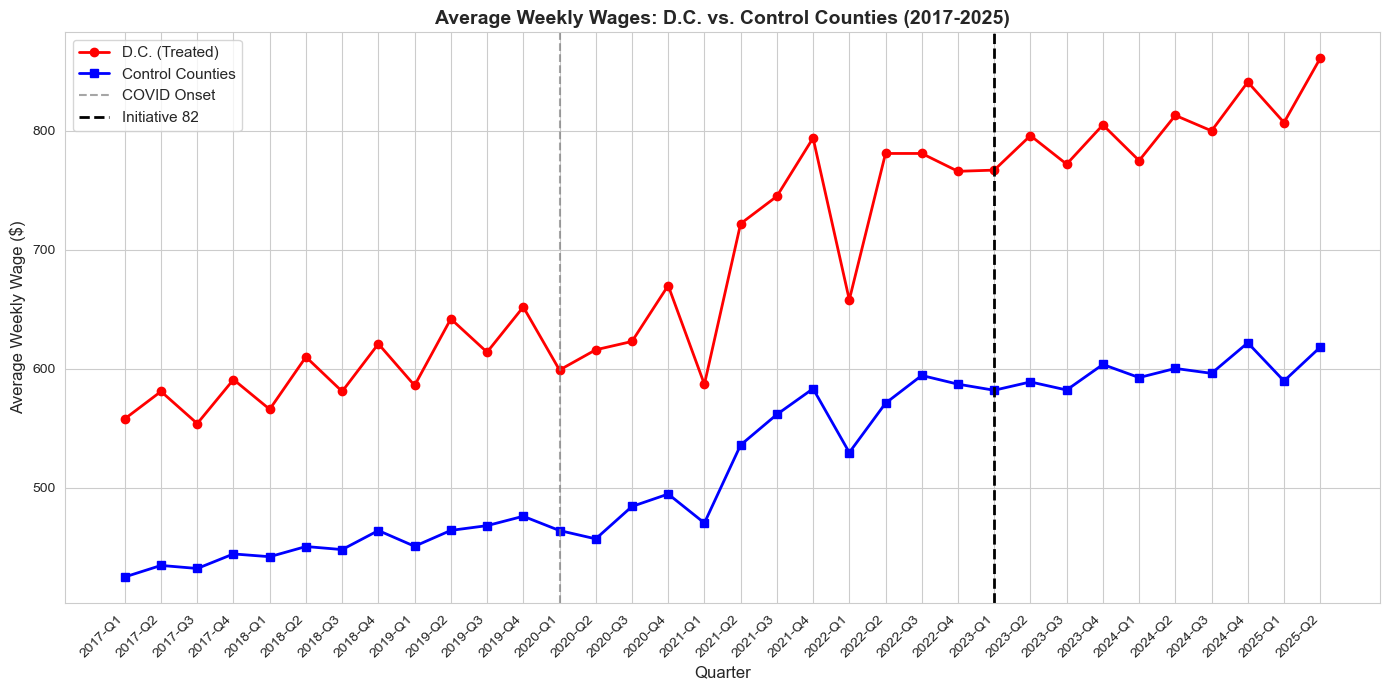

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Quarter label for plotting
data['time_label'] = data['year'].astype(int).astype(str) + '-Q' + data['qtr'].astype(int).astype(str)

# Plotting average weekly wages by quarter
trends = data.groupby(['time_label', 'treated'])['avg_wkly_wage'].mean().reset_index()
dc_trend = trends[trends['treated'] == 1]
control_trend = trends[trends['treated'] == 0]

plt.figure(figsize=(14, 7))
plt.plot(dc_trend['time_label'], dc_trend['avg_wkly_wage'],
         marker='o', linewidth=2, label='D.C. (Treated)', color='red')
plt.plot(control_trend['time_label'], control_trend['avg_wkly_wage'],
         marker='s', linewidth=2, label='Control Counties', color='blue')

plt.axvline(x='2020-Q1', color='gray', linestyle='--', alpha=0.7, label='COVID Onset')
plt.axvline(x='2023-Q1', color='black', linestyle='--', linewidth=2, label='Initiative 82')
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Average Weekly Wage ($)', fontsize=12)
plt.title('Average Weekly Wages: D.C. vs. Control Counties (2017-2025)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

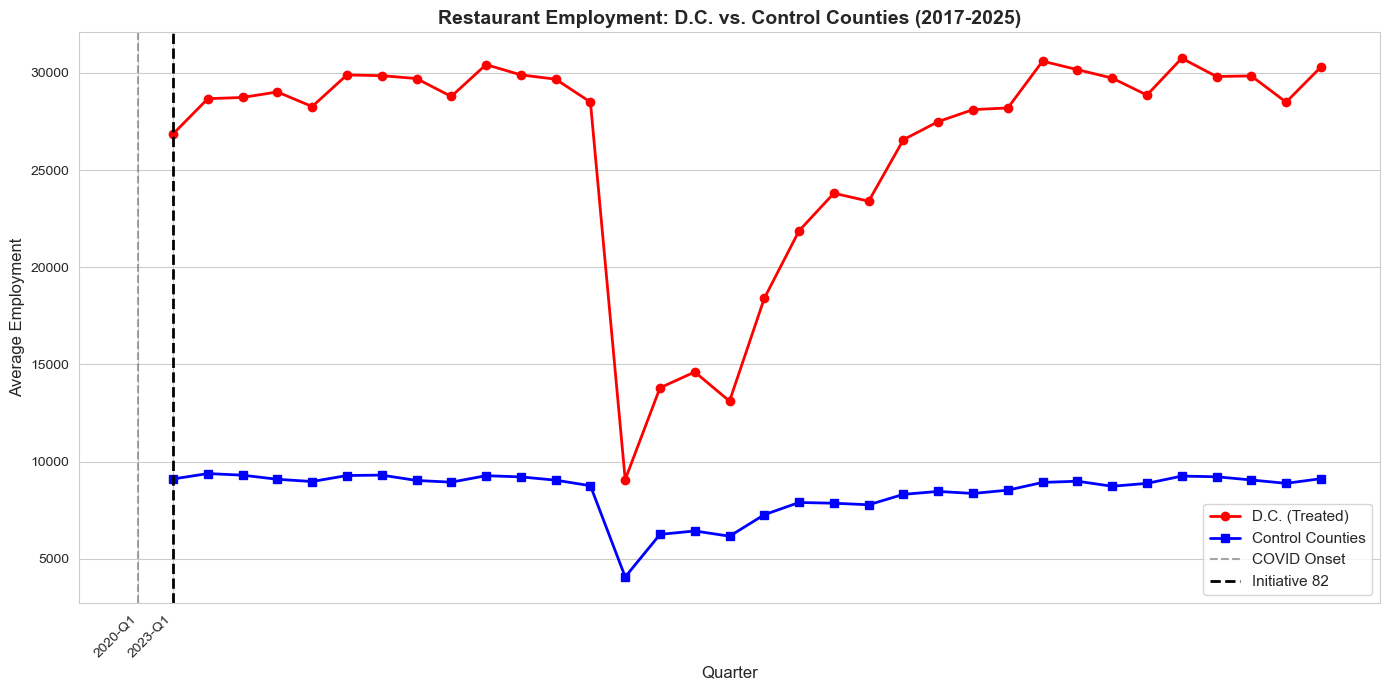

In [14]:
# Same structure for employment
trends_emp = data.groupby(['time', 'treated'])['avg_employment'].mean().reset_index()
dc_emp = trends_emp[trends_emp['treated'] == 1]
control_emp = trends_emp[trends_emp['treated'] == 0]

plt.figure(figsize=(14, 7))
plt.plot(dc_emp['time'], dc_emp['avg_employment'],
         marker='o', linewidth=2, label='D.C. (Treated)', color='red')
plt.plot(control_emp['time'], control_emp['avg_employment'],
         marker='s', linewidth=2, label='Control Counties', color='blue')

plt.axvline(x='2020-Q1', color='gray', linestyle='--', alpha=0.7, label='COVID Onset')
plt.axvline(x='2023-Q1', color='black', linestyle='--', linewidth=2, label='Initiative 82')
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Average Employment', fontsize=12)
plt.title('Restaurant Employment: D.C. vs. Control Counties (2017-2025)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Reading the charts**: Wages show clear co-movement between D.C. and the control counties before 2023, with a visible widening of D.C.'s wage premium after Initiative 82 begins, consistent with a treatment effect. Employment shows a shared COVID-19 shock and recovery path across both groups, which is why one of the robustness checks below re-runs the model excluding the pandemic period.

## 7. Econometric Model: Two-Way Fixed Effects

The main specification is a two-way fixed effects (TWFE) panel regression:$$\ln(Y_{it}) = \alpha + \beta (\text{TipMin}_{it} \times \text{D.C.}_i) + \mu_i + \delta_t + \varepsilon_{it}$$where $\mu_i$ absorbs all time-invariant differences across counties (entity fixed effects) and $\delta_t$ absorbs shocks common to all counties in a given quarter, like COVID-19 (time fixed effects). Standard errors are clustered at the county level. Using the actual tipped minimum wage level (`TipMin_centered`), rather than a simple treated/post binary, lets the model reflect Initiative 82's *gradual* phase-in rather than treating it as a single policy shock.

In [15]:
from linearmodels.panel import PanelOLS

# Binary DiD variable, used only in Robustness Check 1
data['did'] = data['treated'] * data['post']

def run_panel_ols(df, outcome, regressor, label):
    """Fit a TWFE panel regression with county-clustered standard errors and print a one-line summary."""
    d = df.set_index(['area_title', 'time'])
    mod = PanelOLS(
        dependent=d[outcome],
        exog=d[regressor],
        entity_effects=True,
        time_effects=True,
    )    
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    b = res.params[regressor]
    se = res.std_errors[regressor]
    t = res.tstats[regressor]
    p = res.pvalues[regressor]
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f"{label:<45} coef={b:.4f}  SE={se:.4f}  t={t:.3f}  p={p:.4f} {stars}")
    return res

### Main Specification (Full Sample)

In [16]:
print("=== Main Specification: TWFE with TipMin ===")
print(run_panel_ols(data, 'ln_wage', 'TipMin_centered', 'Log Wage'))
print(run_panel_ols(data, 'ln_avg_employment', 'TipMin_centered', 'Log Average Employment'))

=== Main Specification: TWFE with TipMin ===
Log Wage                                      coef=0.0073  SE=0.0019  t=3.917  p=0.0001 ***
                          PanelOLS Estimation Summary                           
Dep. Variable:                ln_wage   R-squared:                        0.0246
Estimator:                   PanelOLS   R-squared (Between):              0.0002
No. Observations:                 340   R-squared (Within):               0.0101
Date:                Wed, Aug 26 2026   R-squared (Overall):              0.0002
Time:                        03:56:46   Log-likelihood                    857.08
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      7.4705
Entities:                          10   P-value                           0.0066
Avg Obs:                       34.000   Distribution:                   F(1,296)
Min Obs:                       34.000                

## 8. Robustness Checks

Three checks test whether the main result holds under different reasonable specifications.

### Robustness Check 1: Binary DiD (treatment as a single shock, not a gradual phase-in)

In [17]:
print("=== Robustness Check 1: Binary DiD (Treated x Post) ===")
print(run_panel_ols(data, 'ln_wage', 'did', 'Log Wage'))
print(run_panel_ols(data, 'ln_avg_employment', 'did', 'Log Average Employment'))

=== Robustness Check 1: Binary DiD (Treated x Post) ===
Log Wage                                      coef=0.0202  SE=0.0050  t=4.057  p=0.0001 ***
                          PanelOLS Estimation Summary                           
Dep. Variable:                ln_wage   R-squared:                        0.0184
Estimator:                   PanelOLS   R-squared (Between):              0.0002
No. Observations:                 340   R-squared (Within):               0.0096
Date:                Wed, Aug 26 2026   R-squared (Overall):              0.0002
Time:                        03:56:47   Log-likelihood                    856.00
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.5393
Entities:                          10   P-value                           0.0192
Avg Obs:                       34.000   Distribution:                   F(1,296)
Min Obs:                       34.000     

### Robustness Check 2: Excluding the COVID-19 Period (2020-2022)

In [18]:
print("\n=== Robustness Check 2: Exclude COVID years (2020-2022) ===")
data_no_covid = data[~data['year'].isin([2020, 2021, 2022])].copy()
print(run_panel_ols(data_no_covid, 'ln_wage', 'TipMin_centered', 'Log Wage'))
print(run_panel_ols(data_no_covid, 'ln_avg_employment', 'TipMin_centered', 'Log Average Employment'))


=== Robustness Check 2: Exclude COVID years (2020-2022) ===
Log Wage                                      coef=0.0065  SE=0.0021  t=3.050  p=0.0026 ***
                          PanelOLS Estimation Summary                           
Dep. Variable:                ln_wage   R-squared:                        0.0298
Estimator:                   PanelOLS   R-squared (Between):              0.0003
No. Observations:                 220   R-squared (Within):               0.0118
Date:                Wed, Aug 26 2026   R-squared (Overall):              0.0003
Time:                        03:56:47   Log-likelihood                    571.33
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.7789
Entities:                          10   P-value                           0.0172
Avg Obs:                       22.000   Distribution:                   F(1,188)
Min Obs:                       22.000

### Robustness Check 3: Contiguous Counties Only

Per Dube (2019), comparisons between *directly bordering* areas better satisfy the parallel trends assumption than comparisons across a wider, less geographically similar set of counties. This check restricts the control group to only the 5 counties that directly border Washington D.C.

In [19]:
dube_counties = [
    'District of Columbia',
    'Montgomery County, Maryland',
    "Prince George's County, Maryland",
    'Arlington County, Virginia',
    'Fairfax County, Virginia',
    'Alexandria City, Virginia'
]

data_dube = data[data['area_title'].isin(dube_counties)]
print("=== Robustness Check 3: Contiguous Counties Only ===")
print(run_panel_ols(data_dube, 'ln_wage', 'TipMin_centered', 'Log Wage - Contiguous Only'))
print(run_panel_ols(data_dube, 'ln_avg_employment', 'TipMin_centered', 'Log Employment - Contiguous Only'))

=== Robustness Check 3: Contiguous Counties Only ===
Log Wage - Contiguous Only                    coef=0.0082  SE=0.0017  t=4.820  p=0.0000 ***
                          PanelOLS Estimation Summary                           
Dep. Variable:                ln_wage   R-squared:                        0.0490
Estimator:                   PanelOLS   R-squared (Between):              0.0003
No. Observations:                 204   R-squared (Within):               0.0192
Date:                Wed, Aug 26 2026   R-squared (Overall):              0.0003
Time:                        03:56:48   Log-likelihood                    518.34
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      8.4424
Entities:                           6   P-value                           0.0042
Avg Obs:                       34.000   Distribution:                   F(1,164)
Min Obs:                       34.000        

## Summary of Findings

A $1 increase in the tipped minimum wage is associated with a **+0.73% increase in average weekly wages** and a **+2.51% increase in average quarterly employment** in D.C.'s full-service restaurant industry, both significant at the 1% level. All three robustness checks support the wage result; the employment result loses significance when COVID-19 years are excluded, suggesting some of the measured employment gain may reflect post-pandemic recovery rather than the policy alone. Full discussion and policy implications are in `write-up.pdf`.